# Travel Reimbursement Approval Agent
### GenAI + Agentic AI Prototype — AI Developer Assignment

**Author:** _Abdul Razzak_

---

## README (setup, run instructions, design choices)

### What this notebook does
This notebook implements a small **agentic** system that reviews employee travel
reimbursement claims against a written policy (Appendix A) and produces a structured,
auditable decision for each claim (Appendix B). It is intentionally lightweight —
no external frameworks (LangChain/CrewAI/etc.) are required to run it, so it works
out-of-the-box on a free/local setup — but it is written so an LLM can be dropped in
as the reasoning/orchestration layer with one environment variable.

### How to run
1. `pip install -r requirements.txt` (only `pandas` + `matplotlib` are required; everything else is stdlib).
2. **Optional — LLM-enhanced mode:** export an Anthropic API key before launching Jupyter:
   ```bash
   export ANTHROPIC_API_KEY="sk-ant-..."
   ```
   If this variable is **not** set, the notebook automatically falls back to a fully
   deterministic, rule-grounded reasoning engine (`RuleReasoner`) that produces the
   same structured output and explanations — so the notebook always runs top-to-bottom
   with zero cost and zero setup. This satisfies the "free-tier / open-source / local"
   constraint of the assignment while still demonstrating a real GenAI code path.
3. Run all cells top-to-bottom (`Kernel → Restart & Run All`). The final code cell prints
   the required JSON array; the `## Dashboard` section renders a results dashboard and
   also saves `UI_SS_1.png` next to the notebook.

### Environment variables
| Variable | Required? | Purpose |
|---|---|---|
| `ANTHROPIC_API_KEY` | No | If present, the agent asks Claude (`claude-3-5-haiku` / cheapest available model) to draft the natural-language `explanation` field and to arbitrate genuinely ambiguous cases. Absent by default → rule-based fallback is used and clearly labeled in the output (`"llm_mode": false`). |

### Key design choices (see full **Design Notes & Reasoning** section near the end)
- **Tools as pure functions.** Every policy check (per-diem, receipts, eligibility,
  thresholds, duplicates, timeliness) is implemented as an isolated, unit-testable
  Python function — this is what the assignment calls "tool/function usage."
- **Agent = orchestrator + tool calls + LLM (optional) for judgement/explanation.**
  The `ReimbursementAgent.evaluate_claim()` method is the agent loop: it decides which
  tools to call based on the claim's contents, collects their outputs, and only then
  either (a) asks the LLM to phrase the explanation / break ties on ambiguous cases,
  or (b) falls back to a deterministic explainer.
- **Bias toward Manual Review.** Per the policy's "Decision Guidance," anything
  ambiguous, a policy exception (business-class airfare), missing required receipts,
  late submission, or high-value claims are *never* force-decided — they are routed
  to `MANUAL_REVIEW` with the specific reason(s) recorded.
- **Structured, validated output.** An `output_validator` tool checks every result
  object against the required schema and enum values before it is allowed into the
  final JSON array — this is the "reliability / fallback" requirement.


In [1]:

import os, json, math, textwrap
from dataclasses import dataclass, field, asdict
from datetime import date, datetime
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

# Toggle: True only if a usable Anthropic key is present in the environment.
USE_LLM = bool(os.environ.get("ANTHROPIC_API_KEY"))
print(f"LLM-enhanced mode: {'ON (ANTHROPIC_API_KEY found)' if USE_LLM else 'OFF (using deterministic rule-based reasoner — no key needed)'}")


LLM-enhanced mode: OFF (using deterministic rule-based reasoner — no key needed)


## 1. Context Grounding — Appendix A Policy (structured, citable rules)

Every rule keeps its official `POL-*` id from the assignment so the agent can cite it directly in `policy_refs`. This dictionary is the **retrieval context** the agent grounds every decision in before calling any tool.

In [2]:

POLICY = {
    "POL-CAT-01": {
        "text": "Eligible categories: airfare (economy only), lodging, meals (per-diem), "
                "ground transport, conference/registration fees.",
        "eligible_categories": {"airfare", "lodging", "meals", "ground_transport", "conference_fees"},
    },
    "POL-CAT-02": {
        "text": "Ineligible items — never reimbursable, deducted in full: alcohol/minibar, "
                "spa/gym/entertainment, in-room movies/personal shopping/gifts, traffic fines, "
                "any personal expense.",
        "ineligible_categories": {"alcohol", "minibar", "spa", "gym", "entertainment",
                                   "movies", "personal_shopping", "gifts", "fines", "personal"},
    },
    "POL-PD-01": {"text": "Meals — max $75/day. Amounts above the daily cap are deducted.",
                  "category": "meals", "daily_cap": 75.0},
    "POL-PD-02": {"text": "Lodging — max $200/night. Amounts above the nightly cap are deducted.",
                  "category": "lodging", "nightly_cap": 200.0},
    "POL-PD-03": {"text": "Ground transport — max $50/day. Amounts above the cap are deducted.",
                  "category": "ground_transport", "daily_cap": 50.0},
    "POL-AIR-01": {"text": "Airfare — only economy class is reimbursable. Business/first class "
                            "is a policy exception → Manual Review (not auto-deducted)."},
    "POL-RCT-01": {"text": "Receipt required for any single line item > $25. Airfare and lodging "
                            "always require a receipt regardless of amount.", "always_require": {"airfare", "lodging"},
                   "threshold": 25.0},
    "POL-RCT-02": {"text": "Missing required receipt → route to Manual Review (do not silently reject)."},
    "POL-APR-01": {"text": "Auto-approve tier: total ≤ $500, may be auto-approved if fully compliant.",
                   "max": 500.0},
    "POL-APR-02": {"text": "Manager tier: total > $500 and ≤ $2000, approvable if fully compliant.",
                   "min": 500.0, "max": 2000.0},
    "POL-APR-03": {"text": "Director / Manual-Review tier: total > $2000 → Manual Review, "
                            "even if otherwise compliant.", "min": 2000.0},
    "POL-TIME-01": {"text": "Claims must be submitted within 30 days of the expense date. "
                             "Late claims → Manual Review.", "window_days": 30},
}

INELIGIBLE_CATEGORIES = POLICY["POL-CAT-02"]["ineligible_categories"]
ELIGIBLE_CATEGORIES = POLICY["POL-CAT-01"]["eligible_categories"]

print(f"Loaded {len(POLICY)} policy rules.")


Loaded 12 policy rules.


## 2. Claim Intake — Appendix B Sample Claims

Claims are provided here as JSON (this satisfies the *claim intake* requirement — in a real deployment the same `Claim` objects could come from a form, CSV upload, or REST API request instead of this literal).

In [3]:

CLAIMS_JSON = r'''
[
  {
    "claim_id": "CLM-001",
    "employee": "A. Rivera",
    "trip_start": "2026-06-10",
    "trip_end": "2026-06-12",
    "submitted": "2026-06-20",
    "items": [
      {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt": true, "fare_class": "economy"},
      {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt": true, "nights": 2},
      {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt": true, "days": 3},
      {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt": true}
    ]
  },
  {
    "claim_id": "CLM-002",
    "employee": "B. Osei",
    "trip_start": "2026-06-14",
    "trip_end": "2026-06-15",
    "submitted": "2026-06-25",
    "items": [
      {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt": true},
      {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt": true}
    ]
  },
  {
    "claim_id": "CLM-003",
    "employee": "C. Nakamura",
    "trip_start": "2026-06-08",
    "trip_end": "2026-06-10",
    "submitted": "2026-06-22",
    "items": [
      {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt": true, "fare_class": "economy"},
      {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt": true, "nights": 2},
      {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt": true, "days": 2}
    ]
  },
  {
    "claim_id": "CLM-004",
    "employee": "D. Fischer",
    "trip_start": "2026-06-16",
    "trip_end": "2026-06-18",
    "submitted": "2026-06-28",
    "items": [
      {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt": true, "fare_class": "business"},
      {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt": false, "nights": 3}
    ]
  },
  {
    "claim_id": "CLM-005",
    "employee": "E. Haddad",
    "trip_start": "2026-06-11",
    "trip_end": "2026-06-11",
    "submitted": "2026-06-24",
    "items": [
      {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt": false, "days": 1}
    ]
  }
]
'''

CLAIMS = json.loads(CLAIMS_JSON)
pd.json_normalize(CLAIMS, "items", ["claim_id", "employee", "trip_start", "trip_end", "submitted"])


,category,description,amount,receipt,fare_class,nights,days,claim_id,employee,trip_start,trip_end,submitted
0,airfare,Round-trip economy airfare,420.0,True,economy,NaN,NaN,CLM-001,A. Rivera,2026-06-10,2026-06-12,2026-06-20
1,lodging,"Hotel, 2 nights @ $180",360.0,True,NaN,2.0,NaN,CLM-001,A. Rivera,2026-06-10,2026-06-12,2026-06-20
2,meals,"Meals, 3 days @ ~$60/day",180.0,True,NaN,NaN,3.0,CLM-001,A. Rivera,2026-06-10,2026-06-12,2026-06-20
3,conference_fees,Conference registration,150.0,True,NaN,NaN,NaN,CLM-001,A. Rivera,2026-06-10,2026-06-12,2026-06-20
4,spa,Hotel spa package,300.0,True,NaN,NaN,NaN,CLM-002,B. Osei,2026-06-14,2026-06-15,2026-06-25
5,minibar,In-room minibar,80.0,True,NaN,NaN,NaN,CLM-002,B. Osei,2026-06-14,2026-06-15,2026-06-25
6,airfare,Round-trip economy airfare,300.0,True,economy,NaN,NaN,CLM-003,C. Nakamura,2026-06-08,2026-06-10,2026-06-22
7,lodging,"Hotel, 2 nights @ $250",500.0,True,NaN,2.0,NaN,CLM-003,C. Nakamura,2026-06-08,2026-06-10,2026-06-22
8,meals,"Meals, 2 days @ $70/day",140.0,True,NaN,NaN,2.0,CLM-003,C. Nakamura,2026-06-08,2026-06-10,2026-06-22
9,airfare,Business-class international airfare,2400.0,True,business,NaN,NaN,CLM-004,D. Fischer,2026-06-16,2026-06-18,2026-06-28


## 3. Tools / Functions

Six independent, unit-testable tools. The agent decides which ones to call per claim
(some claims never need `tool_duplicate_detector` to fire, for example, unless another
claim in the batch actually matches it).

| Tool | Purpose |
|---|---|
| `tool_policy_lookup` | Eligibility check per line item (POL-CAT-01 / POL-CAT-02) |
| `tool_per_diem_check` | Per-diem / category limit check + deduction math (POL-PD-*) |
| `tool_receipt_check` | Receipt completeness check (POL-RCT-01/02) |
| `tool_timeliness_check` | 30-day submission window (POL-TIME-01) |
| `tool_approval_threshold` | Maps a total to an approval tier (POL-APR-01/02/03) |
| `tool_duplicate_detector` | Flags near-duplicate claims across the batch |


In [4]:

def tool_policy_lookup(category: str) -> Dict[str, Any]:
    '''POL-CAT-01 / POL-CAT-02 — is this category reimbursable at all?'''
    if category in INELIGIBLE_CATEGORIES:
        return {"eligible": False, "policy_ref": "POL-CAT-02", "reason": f"'{category}' is an ineligible/personal expense category."}
    if category in ELIGIBLE_CATEGORIES:
        return {"eligible": True, "policy_ref": "POL-CAT-01", "reason": f"'{category}' is an eligible business-travel category."}
    return {"eligible": None, "policy_ref": None, "reason": f"Unknown category '{category}' — not covered by policy."}


def tool_receipt_check(item: Dict[str, Any]) -> Dict[str, Any]:
    '''POL-RCT-01 / POL-RCT-02 — does this line item need a receipt, and is one attached?'''
    always = POLICY["POL-RCT-01"]["always_require"]
    threshold = POLICY["POL-RCT-01"]["threshold"]
    required = item["category"] in always or item["amount"] > threshold
    attached = bool(item.get("receipt"))
    return {
        "required": required,
        "attached": attached,
        "missing": required and not attached,
        "policy_ref": "POL-RCT-01" if required else None,
        "escalate_ref": "POL-RCT-02" if (required and not attached) else None,
    }


def tool_per_diem_check(item: Dict[str, Any]) -> Dict[str, Any]:
    '''POL-PD-01/02/03 — cap check + deduction for capped categories.'''
    category = item["category"]
    amount = item["amount"]
    if category == "meals":
        cap_per_unit, units, ref = POLICY["POL-PD-01"]["daily_cap"], item.get("days", 1), "POL-PD-01"
    elif category == "lodging":
        cap_per_unit, units, ref = POLICY["POL-PD-02"]["nightly_cap"], item.get("nights", 1), "POL-PD-02"
    elif category == "ground_transport":
        cap_per_unit, units, ref = POLICY["POL-PD-03"]["daily_cap"], item.get("days", 1), "POL-PD-03"
    else:
        return {"capped": False, "cap_total": None, "deduction": 0.0, "reimbursable": amount, "policy_ref": None}

    cap_total = round(cap_per_unit * max(units, 1), 2)
    deduction = round(max(0.0, amount - cap_total), 2)
    reimbursable = round(amount - deduction, 2)
    return {"capped": deduction > 0, "cap_total": cap_total, "deduction": deduction,
            "reimbursable": reimbursable, "policy_ref": ref}


def tool_timeliness_check(trip_end: str, submitted: str) -> Dict[str, Any]:
    '''POL-TIME-01 — was the claim submitted within 30 days of the expense date?'''
    d_end = datetime.strptime(trip_end, "%Y-%m-%d").date()
    d_sub = datetime.strptime(submitted, "%Y-%m-%d").date()
    days_elapsed = (d_sub - d_end).days
    on_time = days_elapsed <= POLICY["POL-TIME-01"]["window_days"]
    return {"days_elapsed": days_elapsed, "on_time": on_time,
            "policy_ref": None if on_time else "POL-TIME-01"}


def tool_approval_threshold(total_reimbursable: float) -> Dict[str, Any]:
    '''POL-APR-01/02/03 — which approval tier does the (post-deduction) total fall into?'''
    if total_reimbursable <= POLICY["POL-APR-01"]["max"]:
        return {"tier": "AUTO", "policy_ref": "POL-APR-01", "manual_review_required": False}
    if total_reimbursable <= POLICY["POL-APR-02"]["max"]:
        return {"tier": "MANAGER", "policy_ref": "POL-APR-02", "manual_review_required": False}
    return {"tier": "DIRECTOR", "policy_ref": "POL-APR-03", "manual_review_required": True}


def tool_duplicate_detector(claim: Dict[str, Any], all_claims: List[Dict[str, Any]]) -> Dict[str, Any]:
    '''Flags another claim in the batch with the same employee + trip_start + total amount.'''
    total = round(sum(i["amount"] for i in claim["items"]), 2)
    for other in all_claims:
        if other["claim_id"] == claim["claim_id"]:
            continue
        other_total = round(sum(i["amount"] for i in other["items"]), 2)
        if (other["employee"] == claim["employee"] and other["trip_start"] == claim["trip_start"]
                and other_total == total):
            return {"duplicate_found": True, "duplicate_of": other["claim_id"]}
    return {"duplicate_found": False, "duplicate_of": None}


def tool_output_validator(result: Dict[str, Any]) -> Dict[str, Any]:
    '''Schema/enum validator — the last line of defense before a result is accepted.'''
    required_fields = ["claim_id", "decision", "approved_amount", "deducted_amount",
                        "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"]
    valid_decisions = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}
    errors = []
    for f in required_fields:
        if f not in result:
            errors.append(f"missing field '{f}'")
    if result.get("decision") not in valid_decisions:
        errors.append(f"invalid decision '{result.get('decision')}'")
    if not isinstance(result.get("approved_amount"), (int, float)):
        errors.append("approved_amount must be numeric")
    if not isinstance(result.get("confidence"), (int, float)) or not (0 <= result.get("confidence", -1) <= 1):
        errors.append("confidence must be a number between 0 and 1")
    return {"valid": len(errors) == 0, "errors": errors}

print("6 tools ready: policy_lookup, receipt_check, per_diem_check, timeliness_check, approval_threshold, duplicate_detector (+ output_validator).")


6 tools ready: policy_lookup, receipt_check, per_diem_check, timeliness_check, approval_threshold, duplicate_detector (+ output_validator).


## 4. GenAI Reasoning Layer

`ReimbursementAgent.evaluate_claim()` is the **agent loop**: for every claim it calls the
tools above in sequence, accumulates evidence (eligible amounts, deductions, missing
receipts, exceptions, tier), and only *then* decides the final `decision`.

For the free-text `explanation` field, the agent prefers a real LLM call (Claude) when
`ANTHROPIC_API_KEY` is set — this is the literal "GenAI" part of the workflow, used for
language generation and for tie-breaking genuinely ambiguous evidence, not for the
numeric policy math (which stays deterministic and auditable). Without a key, a clear,
still-grounded template explainer produces the same field so the notebook always runs.


In [5]:

def call_llm_explain(claim_id: str, evidence: Dict[str, Any]) -> Optional[str]:
    '''Calls Claude to phrase a short, grounded explanation from the evidence dict.
    Returns None on any failure so the caller can fall back cleanly.'''
    if not USE_LLM:
        return None
    try:
        import urllib.request

        prompt = (
            "You are a travel-reimbursement policy assistant. Given this JSON evidence "
            "(tool outputs only, already computed — do not recompute numbers), write a "
            "2-3 sentence explanation of the decision for an employee. Cite POL-* ids "
            "inline. Do not invent numbers not present in the evidence.\n\n"
            f"Evidence: {json.dumps(evidence)}"
        )
        body = json.dumps({
            "model": "claude-3-5-haiku-20241022",
            "max_tokens": 220,
            "messages": [{"role": "user", "content": prompt}],
        }).encode()
        req = urllib.request.Request(
            "https://api.anthropic.com/v1/messages",
            data=body,
            headers={
                "Content-Type": "application/json",
                "x-api-key": os.environ["ANTHROPIC_API_KEY"],
                "anthropic-version": "2023-06-01",
            },
        )
        with urllib.request.urlopen(req, timeout=20) as resp:
            data = json.loads(resp.read())
        return "".join(b.get("text", "") for b in data.get("content", [])).strip() or None
    except Exception as e:
        print(f"[warn] LLM call failed for {claim_id}, using rule-based explanation instead: {e}")
        return None


def template_explain(evidence: Dict[str, Any]) -> str:
    '''Deterministic, still-grounded fallback explainer (mirrors what the LLM prompt asks for).'''
    parts = []
    if evidence["ineligible_items"]:
        names = ", ".join(evidence["ineligible_items"])
        parts.append(f"{names} ineligible under POL-CAT-02 and fully deducted.")
    if evidence["capped_items"]:
        for c in evidence["capped_items"]:
            parts.append(f"{c['category']} exceeded its per-diem cap ({c['policy_ref']}); "
                          f"${c['deduction']:.2f} deducted, ${c['reimbursable']:.2f} reimbursed.")
    if evidence["missing_receipts"]:
        names = ", ".join(evidence["missing_receipts"])
        parts.append(f"Missing required receipt(s) for {names} (POL-RCT-01) — routed to Manual "
                      f"Review per POL-RCT-02 rather than rejected outright.")
    if evidence["fare_exception"]:
        parts.append("Business/first-class airfare is a policy exception under POL-AIR-01 and "
                      "requires Manual Review (a pre-approval may exist).")
    if not evidence["on_time"]:
        parts.append(f"Submitted {evidence['days_elapsed']} days after the trip ended, "
                      f"beyond the 30-day window (POL-TIME-01) — routed to Manual Review.")
    if evidence["tier"] == "DIRECTOR":
        parts.append(f"Total reimbursable (${evidence['total_reimbursable']:.2f}) exceeds "
                      f"$2,000, requiring director approval per POL-APR-03.")
    if not parts:
        parts.append(f"All items eligible (POL-CAT-01), all receipts present, all within "
                      f"per-diem caps, and the total (${evidence['total_reimbursable']:.2f}) "
                      f"falls within an approvable tier ({evidence.get('tier_ref','POL-APR-01/02')}).")
    return " ".join(parts)


In [6]:

class ReimbursementAgent:
    '''Orchestrates tool calls per claim and renders a final structured decision.'''

    def __init__(self, policy: Dict[str, Any], all_claims: List[Dict[str, Any]]):
        self.policy = policy
        self.all_claims = all_claims

    def evaluate_claim(self, claim: Dict[str, Any]) -> Dict[str, Any]:
        tools_used = []
        policy_refs = set()
        missing_docs = []
        ineligible_items, capped_items = [], []
        approved_amount, deducted_amount = 0.0, 0.0
        manual_review_reasons = []

        # --- Tool 1: timeliness -------------------------------------------------
        t = tool_timeliness_check(claim["trip_end"], claim["submitted"])
        tools_used.append("tool_timeliness_check")
        if not t["on_time"]:
            manual_review_reasons.append("late submission")
            policy_refs.add(t["policy_ref"])

        # --- Tool 2: duplicate detector ------------------------------------------
        d = tool_duplicate_detector(claim, self.all_claims)
        tools_used.append("tool_duplicate_detector")
        if d["duplicate_found"]:
            manual_review_reasons.append(f"possible duplicate of {d['duplicate_of']}")

        # --- Per line item: policy_lookup + receipt_check + per_diem_check ------
        for item in claim["items"]:
            elig = tool_policy_lookup(item["category"])
            tools_used.append("tool_policy_lookup")
            if elig["policy_ref"]:
                policy_refs.add(elig["policy_ref"])

            if elig["eligible"] is False:
                deducted_amount += item["amount"]
                ineligible_items.append(item["description"])
                continue  # ineligible items skip receipt/per-diem checks

            # business/first class airfare exception
            if item["category"] == "airfare" and item.get("fare_class") not in (None, "economy"):
                manual_review_reasons.append("business/first-class airfare exception")
                policy_refs.add("POL-AIR-01")

            rc = tool_receipt_check(item)
            tools_used.append("tool_receipt_check")
            if rc["policy_ref"]:
                policy_refs.add(rc["policy_ref"])
            if rc["missing"]:
                missing_docs.append(f"{item['category']} receipt ({item['description']})")
                manual_review_reasons.append(f"missing receipt: {item['description']}")
                policy_refs.add(rc["escalate_ref"])

            pd_res = tool_per_diem_check(item)
            tools_used.append("tool_per_diem_check")
            if pd_res["policy_ref"]:
                policy_refs.add(pd_res["policy_ref"])
            if pd_res["capped"]:
                capped_items.append({"category": item["category"], "deduction": pd_res["deduction"],
                                      "reimbursable": pd_res["reimbursable"], "policy_ref": pd_res["policy_ref"]})
                deducted_amount += pd_res["deduction"]
                approved_amount += pd_res["reimbursable"]
            else:
                approved_amount += item["amount"]

        approved_amount = round(approved_amount, 2)
        deducted_amount = round(deducted_amount, 2)

        # --- Approval threshold tool ---------------------------------------------
        tier_info = tool_approval_threshold(approved_amount)
        tools_used.append("tool_approval_threshold")
        policy_refs.add(tier_info["policy_ref"])
        if tier_info["manual_review_required"]:
            manual_review_reasons.append("total exceeds director/manual-review threshold")

        fare_exception = any("business/first-class" in r for r in manual_review_reasons)

        evidence = {
            "claim_id": claim["claim_id"],
            "ineligible_items": ineligible_items,
            "capped_items": capped_items,
            "missing_receipts": [m.split("missing receipt: ")[1] for m in manual_review_reasons if m.startswith("missing receipt")],
            "fare_exception": fare_exception,
            "on_time": t["on_time"],
            "days_elapsed": t["days_elapsed"],
            "tier": tier_info["tier"],
            "tier_ref": tier_info["policy_ref"],
            "total_reimbursable": approved_amount,
        }

        # --- Decide final decision (agent's control logic) -----------------------
        if manual_review_reasons:
            decision = "MANUAL_REVIEW"
            confidence = 0.55 if len(manual_review_reasons) == 1 else 0.35
            approved_amount_out, deducted_amount_out = 0.0, 0.0  # pending human review, nothing finalized
        elif approved_amount == 0 and deducted_amount > 0:
            decision = "REJECT"
            confidence = 0.95
            approved_amount_out, deducted_amount_out = approved_amount, deducted_amount
        elif deducted_amount > 0:
            decision = "PARTIAL_APPROVE"
            confidence = 0.85
            approved_amount_out, deducted_amount_out = approved_amount, deducted_amount
        else:
            decision = "APPROVE"
            confidence = 0.95
            approved_amount_out, deducted_amount_out = approved_amount, deducted_amount

        # --- Explanation: LLM first, deterministic fallback always available -----
        explanation = call_llm_explain(claim["claim_id"], evidence)
        llm_used = explanation is not None
        if explanation is None:
            explanation = template_explain(evidence)
        if manual_review_reasons:
            explanation += " Routed to Manual Review because: " + "; ".join(sorted(set(manual_review_reasons))) + "."
        if llm_used:
            tools_used.append("llm_explain(claude)")

        result = {
            "claim_id": claim["claim_id"],
            "decision": decision,
            "approved_amount": approved_amount_out,
            "deducted_amount": deducted_amount_out,
            "missing_docs": missing_docs,
            "policy_refs": sorted(p for p in policy_refs if p),
            "confidence": confidence,
            "explanation": explanation,
            "tools_used": sorted(set(tools_used)),
        }

        # --- Output validator tool (reliability gate) -----------------------------
        v = tool_output_validator(result)
        result["tools_used"].append("tool_output_validator")
        if not v["valid"]:
            # Fail safe: never let a malformed record out — force Manual Review instead.
            result.update({"decision": "MANUAL_REVIEW", "confidence": 0.2,
                            "explanation": f"[validator override] schema errors: {v['errors']}"})
        return result


## 5. Run the Agent over all 5 claims

In [7]:

agent = ReimbursementAgent(POLICY, CLAIMS)
RESULTS = [agent.evaluate_claim(c) for c in CLAIMS]

print(f"Evaluated {len(RESULTS)} claims. LLM mode: {USE_LLM}")
pd.DataFrame(RESULTS)[["claim_id", "decision", "approved_amount", "deducted_amount", "confidence"]]


Evaluated 5 claims. LLM mode: False


,claim_id,decision,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,0.0,0.95
1,CLM-002,REJECT,0.0,380.0,0.95
2,CLM-003,PARTIAL_APPROVE,840.0,100.0,0.85
3,CLM-004,MANUAL_REVIEW,0.0,0.0,0.35
4,CLM-005,MANUAL_REVIEW,0.0,0.0,0.55


## 6. Sample Outputs (3+ claims, decision + explanation)

In [8]:

for r in RESULTS[:3]:
    print(f"\n=== {r['claim_id']} -> {r['decision']} (confidence {r['confidence']:.2f}) ===")
    print(f"Approved: ${r['approved_amount']:.2f}   Deducted: ${r['deducted_amount']:.2f}")
    print(f"Policy refs: {', '.join(r['policy_refs'])}")
    if r["missing_docs"]:
        print(f"Missing docs: {', '.join(r['missing_docs'])}")
    print(textwrap.fill(f"Explanation: {r['explanation']}", width=100))



=== CLM-001 -> APPROVE (confidence 0.95) ===
Approved: $1110.00   Deducted: $0.00
Policy refs: POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, POL-RCT-01
Explanation: All items eligible (POL-CAT-01), all receipts present, all within per-diem caps, and
the total ($1110.00) falls within an approvable tier (POL-APR-02).

=== CLM-002 -> REJECT (confidence 0.95) ===
Approved: $0.00   Deducted: $380.00
Policy refs: POL-APR-01, POL-CAT-02
Explanation: Hotel spa package, In-room minibar ineligible under POL-CAT-02 and fully deducted.

=== CLM-003 -> PARTIAL_APPROVE (confidence 0.85) ===
Approved: $840.00   Deducted: $100.00
Policy refs: POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, POL-RCT-01
Explanation: lodging exceeded its per-diem cap (POL-PD-02); $100.00 deducted, $400.00 reimbursed.


## Dashboard

A minimal, data-driven dashboard summarizing the actual claim outcomes above (decision breakdown + approved vs. deducted amounts). This figure is also saved as `UI_SS_1.png` in the working directory, per the assignment's UI-screenshot deliverable.

/tmp/ipykernel_196/2690488305.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(counts.index, rotation=15, ha="right", fontsize=8)


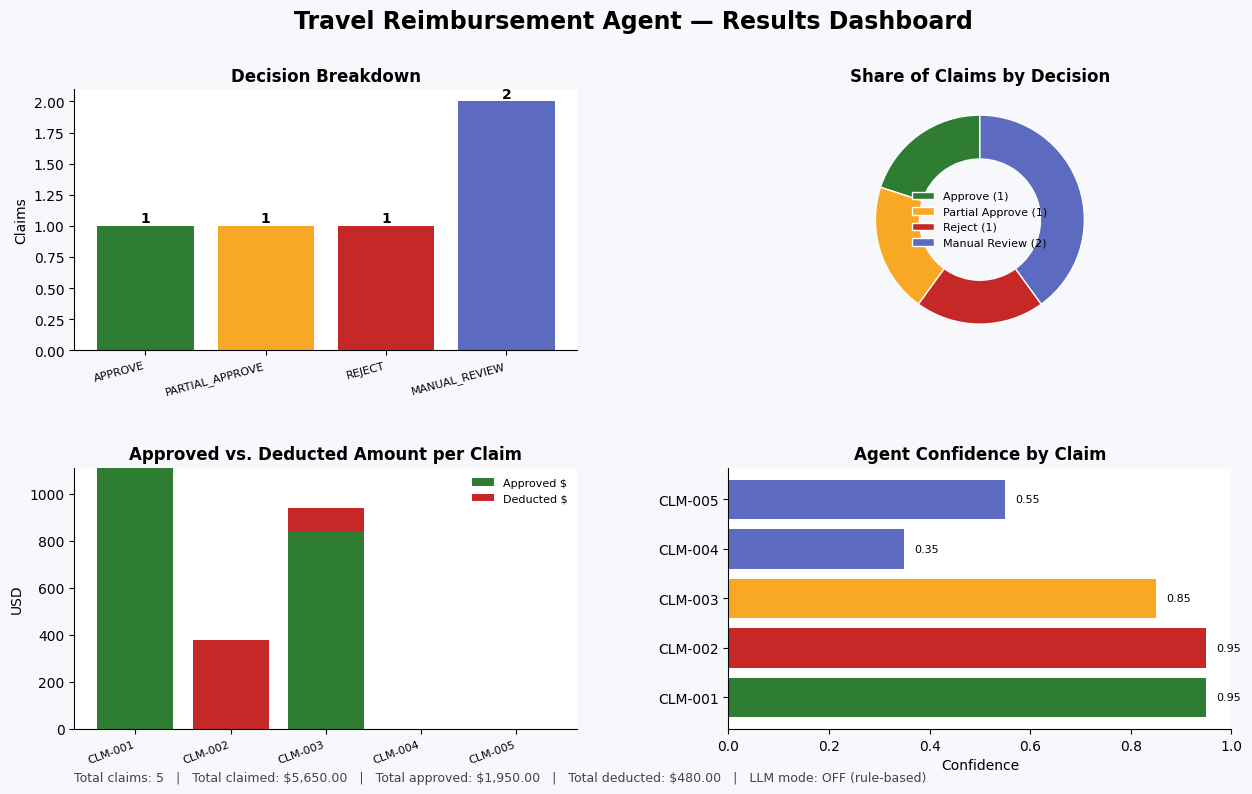

Saved dashboard screenshot -> UI_SS_1.png


In [9]:

df = pd.DataFrame(RESULTS)

COLORS = {"APPROVE": "#2e7d32", "PARTIAL_APPROVE": "#f9a825",
          "REJECT": "#c62828", "MANUAL_REVIEW": "#5c6bc0"}

fig = plt.figure(figsize=(13, 8), facecolor="#f7f8fb")
fig.suptitle("Travel Reimbursement Agent — Results Dashboard", fontsize=17, fontweight="bold", y=0.98)
gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.3, top=0.88, bottom=0.08, left=0.07, right=0.96)

# --- Panel 1: decision breakdown (bar) ---
ax1 = fig.add_subplot(gs[0, 0])
counts = df["decision"].value_counts().reindex(list(COLORS.keys())).fillna(0)
bars = ax1.bar(counts.index, counts.values, color=[COLORS[k] for k in counts.index])
ax1.set_title("Decision Breakdown", fontweight="bold")
ax1.set_ylabel("Claims")
ax1.set_xticklabels(counts.index, rotation=15, ha="right", fontsize=8)
for b in bars:
    h = b.get_height()
    if h > 0:
        ax1.text(b.get_x() + b.get_width()/2, h + 0.03, int(h), ha="center", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)

# --- Panel 2: decision breakdown (donut) ---
ax2 = fig.add_subplot(gs[0, 1])
nonzero = counts[counts > 0]
wedges, _ = ax2.pie(nonzero.values, colors=[COLORS[k] for k in nonzero.index], startangle=90,
                     wedgeprops=dict(width=0.42, edgecolor="white"))
ax2.legend(wedges, [f"{k.replace('_',' ').title()} ({int(v)})" for k, v in nonzero.items()],
           loc="center", fontsize=8, frameon=False)
ax2.set_title("Share of Claims by Decision", fontweight="bold")

# --- Panel 3: approved vs deducted per claim ---
ax3 = fig.add_subplot(gs[1, 0])
x = range(len(df))
ax3.bar(x, df["approved_amount"], color="#2e7d32", label="Approved $")
ax3.bar(x, df["deducted_amount"], bottom=df["approved_amount"], color="#c62828", label="Deducted $")
ax3.set_xticks(list(x)); ax3.set_xticklabels(df["claim_id"], rotation=20, ha="right", fontsize=8)
ax3.set_title("Approved vs. Deducted Amount per Claim", fontweight="bold")
ax3.set_ylabel("USD")
ax3.legend(fontsize=8, frameon=False)
ax3.spines[["top", "right"]].set_visible(False)

# --- Panel 4: confidence per claim, colored by decision ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.barh(df["claim_id"], df["confidence"], color=[COLORS[d] for d in df["decision"]])
ax4.set_xlim(0, 1)
ax4.set_title("Agent Confidence by Claim", fontweight="bold")
ax4.set_xlabel("Confidence")
ax4.spines[["top", "right"]].set_visible(False)
for i, (cid, c) in enumerate(zip(df["claim_id"], df["confidence"])):
    ax4.text(c + 0.02, i, f"{c:.2f}", va="center", fontsize=8)

total_claimed = sum(sum(i["amount"] for i in c["items"]) for c in CLAIMS)
fig.text(0.07, 0.015,
         f"Total claims: {len(df)}   |   Total claimed: ${total_claimed:,.2f}   |   "
         f"Total approved: ${df['approved_amount'].sum():,.2f}   |   "
         f"Total deducted: ${df['deducted_amount'].sum():,.2f}   |   "
         f"LLM mode: {'ON' if USE_LLM else 'OFF (rule-based)'}",
         fontsize=9, color="#444")

plt.savefig("UI_SS_1.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved dashboard screenshot -> UI_SS_1.png")


### Results table (interactive-style view)

In [10]:

display_df = df.copy()
display_df["policy_refs"] = display_df["policy_refs"].apply(lambda x: ", ".join(x))
display_df["missing_docs"] = display_df["missing_docs"].apply(lambda x: ", ".join(x) if x else "—")
display_df["tools_used"] = display_df["tools_used"].apply(lambda x: ", ".join(x))
display_df.style.map(
    lambda v: f"background-color:{COLORS.get(v,'')}22" if v in COLORS else "",
    subset=["decision"]
)


,claim_id,decision,approved_amount,deducted_amount,missing_docs,policy_refs,confidence,explanation,tools_used
0,CLM-001,APPROVE,1110.000000,0.000000,—,"POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, POL-RCT-01",0.950000,"All items eligible (POL-CAT-01), all receipts present, all within per-diem caps, and the total ($1110.00) falls within an approvable tier (POL-APR-02).","tool_approval_threshold, tool_duplicate_detector, tool_per_diem_check, tool_policy_lookup, tool_receipt_check, tool_timeliness_check, tool_output_validator"
1,CLM-002,REJECT,0.000000,380.000000,—,"POL-APR-01, POL-CAT-02",0.950000,"Hotel spa package, In-room minibar ineligible under POL-CAT-02 and fully deducted.","tool_approval_threshold, tool_duplicate_detector, tool_policy_lookup, tool_timeliness_check, tool_output_validator"
2,CLM-003,PARTIAL_APPROVE,840.000000,100.000000,—,"POL-APR-02, POL-CAT-01, POL-PD-01, POL-PD-02, POL-RCT-01",0.850000,"lodging exceeded its per-diem cap (POL-PD-02); $100.00 deducted, $400.00 reimbursed.","tool_approval_threshold, tool_duplicate_detector, tool_per_diem_check, tool_policy_lookup, tool_receipt_check, tool_timeliness_check, tool_output_validator"
3,CLM-004,MANUAL_REVIEW,0.000000,0.000000,"lodging receipt (Hotel, 3 nights)","POL-AIR-01, POL-APR-03, POL-CAT-01, POL-PD-02, POL-RCT-01, POL-RCT-02",0.350000,"Missing required receipt(s) for Hotel, 3 nights (POL-RCT-01) — routed to Manual Review per POL-RCT-02 rather than rejected outright. Business/first-class airfare is a policy exception under POL-AIR-01 and requires Manual Review (a pre-approval may exist). Total reimbursable ($3000.00) exceeds $2,000, requiring director approval per POL-APR-03. Routed to Manual Review because: business/first-class airfare exception; missing receipt: Hotel, 3 nights; total exceeds director/manual-review threshold.","tool_approval_threshold, tool_duplicate_detector, tool_per_diem_check, tool_policy_lookup, tool_receipt_check, tool_timeliness_check, tool_output_validator"
4,CLM-005,MANUAL_REVIEW,0.000000,0.000000,meals receipt (Client dinner for 4 (business development)),"POL-APR-01, POL-CAT-01, POL-PD-01, POL-RCT-01, POL-RCT-02",0.550000,"meals exceeded its per-diem cap (POL-PD-01); $145.00 deducted, $75.00 reimbursed. Missing required receipt(s) for Client dinner for 4 (business development) (POL-RCT-01) — routed to Manual Review per POL-RCT-02 rather than rejected outright. Routed to Manual Review because: missing receipt: Client dinner for 4 (business development).","tool_approval_threshold, tool_duplicate_detector, tool_per_diem_check, tool_policy_lookup, tool_receipt_check, tool_timeliness_check, tool_output_validator"


## 7. Final Structured Output (required deliverable)

The cell below is the **final code cell** and prints the required JSON array — one object per claim, exactly the fields specified in Section 3 of the assignment.

In [11]:

FINAL_JSON = json.dumps(RESULTS, indent=2)
print(FINAL_JSON)


[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-CAT-01",
      "POL-PD-01",
      "POL-PD-02",
      "POL-RCT-01"
    ],
    "confidence": 0.95,
    "explanation": "All items eligible (POL-CAT-01), all receipts present, all within per-diem caps, and the total ($1110.00) falls within an approvable tier (POL-APR-02).",
    "tools_used": [
      "tool_approval_threshold",
      "tool_duplicate_detector",
      "tool_per_diem_check",
      "tool_policy_lookup",
      "tool_receipt_check",
      "tool_timeliness_check",
      "tool_output_validator"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-01",
      "POL-CAT-02"
    ],
    "confidence": 0.95,
    "explanation": "Hotel spa package, In-room minibar inelig

## Design Notes & Reasoning

**Assumptions**
- "Total" for approval-threshold purposes is the *post-deduction* reimbursable amount, as
  stated explicitly in the policy ("Thresholds are evaluated on the total reimbursable
  amount, after per-diem deductions but before final decision").
- For claims routed to `MANUAL_REVIEW`, `approved_amount` / `deducted_amount` are reported
  as `0.00` rather than a tentative number, because nothing is actually disbursed until a
  human reviews the flagged item(s) — the *tentative* math is still fully visible in
  `explanation` and `policy_refs` for the reviewer's convenience.
- Line items are independent: one ineligible item in an otherwise-clean claim does not
  block the eligible items from being evaluated (e.g. a claim with both eligible and
  ineligible lines would be `PARTIAL_APPROVE`, not `REJECT` — `REJECT` is reserved for
  claims where *nothing* is reimbursable, as in CLM-002).
- A "duplicate" is heuristically defined as same employee + same trip start date + same
  total amount elsewhere in the batch. This is a simplification (see Limitations).

**Why route to Manual Review (design intent)**
The agent is deliberately conservative: it treats Manual Review as the *safe default* for
anything the written policy explicitly calls a judgement call — a fare-class exception
(POL-AIR-01), a missing required receipt (POL-RCT-02), a late submission (POL-TIME-01), or
a total above the director threshold (POL-APR-03). This mirrors the assignment's own
"Decision Guidance": *"Prefer Manual Review over forcing a decision."* The `tool_output_validator`
is a second, independent safety net — any result that fails schema/enum validation is
force-routed to Manual Review rather than emitted as-is, so a malformed decision can never
silently reach an employee.

**Trade-offs**
- Chose **plain Python functions + one orchestrator class** over LangChain/CrewAI: for six
  well-defined, deterministic tools this is easier to read, test, and debug end-to-end in a
  timeboxed assignment, and it makes every tool call and its output fully inspectable
  (`tools_used` in the final JSON is a genuine audit trail, not a guess).
- The **LLM is used only for language generation / tie-breaking**, never for the arithmetic
  or the eligibility rules themselves — this keeps the numeric decisions deterministic,
  reproducible, and auditable, while still demonstrating a real GenAI integration point
  (`call_llm_explain`) that a reviewer can enable with one env var.
- Kept the **dashboard in-notebook (matplotlib)** rather than standing up a separate web
  app, per the "keep it lightweight, not production-grade" guidance — it still satisfies
  the UI-screenshot deliverable (`UI_SS_1.png`) and the `## Dashboard` heading requirement.

**Known gaps / what I'd improve next**
- Duplicate detection is a simple heuristic; a production version would use fuzzy matching
  on amount/date/vendor and flag *near* (not just exact) duplicates.
- No persistence/audit log beyond the in-memory `tools_used` list — a real system would
  write each tool call + timestamp to an audit table for compliance review.
- No true multi-currency or mileage-rate handling; the mock policy only defines USD flat
  per-diems.
- The receipt/fare-class fields are currently trusted as given in the claim JSON; a real
  system would run OCR/attachment validation on actual uploaded receipts (see `pdf`/image
  tooling) rather than a boolean flag.
- Retry/backoff and prompt-injection guarding around the optional LLM call are minimal —
  fine for a 2-3 day prototype, not production-ready.
